In [ ]:
!pip install torch numpy matplotlib

In [ ]:
import time, random, re, collections
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [ ]:
def set_seed(s=0):
  random.seed(s); np.random.seed(s)
  torch.manual_seed(s); torch.cuda.manual_seed_all(s)

In [ ]:
set_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:',device)
if device.type == 'cuda':
  print('GPU  :',torch.cuda.get_device_name(0))

Device: cuda
GPU  : Tesla T4


In [ ]:
!pip install -q datasets

In [ ]:
from datasets import load_dataset

In [ ]:
raw = load_dataset('stanfordnlp/imdb')
set_seed(0)
train_raw = raw['train'].shuffle(seed=0).select(range(8000))
test_raw  = raw['test'].shuffle(seed=0).select(range(2000))
print('train reviews:', len(train_raw), '| test reviews:', len(test_raw))
print('example label (1=pos,0=neg):', train_raw[0]['label'])
print('example text:', train_raw[0]['text'][:200], '...')

train reviews: 8000 | test reviews: 2000
example label (1=pos,0=neg): 1
example text: We always watch American movies with their particular accents from each region (south, west, etc). We have the same here. All foreign people must to watch this movie and need to have a open mind to ac ...


In [ ]:
TOKEN_RE = re.compile(r'[a-z]+')

In [ ]:
def tokenize(text):
  return TOKEN_RE.findall(text.lower())

In [ ]:
PAD,UNK = 0,1
VOCAB_SIZE = 20000
MAX_LEN = 300

In [ ]:
counter = collections.Counter()
for ex in train_raw:
  counter.update(tokenize(ex['text']))

In [ ]:
itos = ['<pad>', '<unk>'] + [w for w, _ in counter.most_common(VOCAB_SIZE - 2)]
stoi = {w : i for i , w in enumerate(itos)}
print('vocab size:',len(itos))
print('top words:',itos[2:12])

vocab size: 20000
top words: ['the', 'a', 'and', 'of', 'to', 'is', 'br', 'it', 'in', 'i']


In [ ]:
def encode(text):
  ids = [stoi.get(tok,UNK) for tok in tokenize(text)[:MAX_LEN]]
  if len(ids) < MAX_LEN:
    ids = ids + [PAD] * (MAX_LEN - len(ids))
  return ids

def build_tensors(ds):
  X = torch.tensor([encode(ex['text']) for ex in ds], dtype=torch.long)
  y = torch.tensor([ex['label'] for ex in ds],dtype=torch.long)
  return X,y

In [ ]:
X_train_full,y_train_full = build_tensors(train_raw)
X_test,y_test = build_tensors(test_raw)

In [ ]:
n_val = 1500
X_val,y_val = X_train_full[:n_val],y_train_full[:n_val]
X_train,y_train = X_train_full[n_val:],y_train_full[n_val:]

In [ ]:
print('X_train',X_train.shape,'| X_val',X_val.shape,'|X_test',X_test.shape)
print('each review -> a length-%d is sequence' % MAX_LEN)

X_train torch.Size([6500, 300]) | X_val torch.Size([1500, 300]) |X_test torch.Size([2000, 300])
each review -> a length-300 is sequence


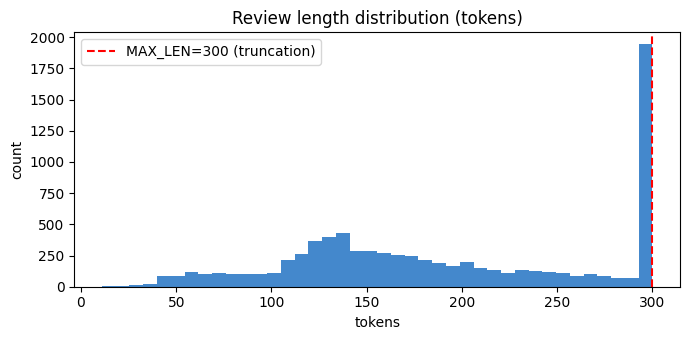

In [ ]:
lengths = [min(len(tokenize(ex['text'])), MAX_LEN) for ex in train_raw]
plt.figure(figsize=(7, 3.5))
plt.hist(lengths, bins=40, color='#48c')
plt.axvline(MAX_LEN, color='red', ls='--', label=f'MAX_LEN={MAX_LEN} (truncation)')
plt.title('Review length distribution (tokens)'); plt.xlabel('tokens'); plt.ylabel('count')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
def make_loaders(Xtr,ytr,Xva,yva,batch_size=64):
  tr = DataLoader(TensorDataset(Xtr,ytr),batch_size=batch_size,shuffle=True)
  va = DataLoader(TensorDataset(Xva,yva),batch_size=256,shuffle=False)
  return tr,va

In [ ]:
train_loader,val_loader = make_loaders(X_train,y_train,X_val,y_val)
test_loader = DataLoader(TensorDataset(X_test,y_test),batch_size=256)

In [ ]:
class RecurrentClassifier(nn.Module):
    def __init__(self, kind='lstm', vocab_size=VOCAB_SIZE, embed_dim=100,
                 hidden_size=128, num_layers=1, num_classes=2, dropout=0.0):
        super().__init__()
        self.kind = kind
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        rnn = {'lstm': nn.LSTM, 'rnn': nn.RNN, 'gru': nn.GRU}[kind]
        self.rnn = rnn(embed_dim, hidden_size, num_layers, batch_first=True,
                       dropout=dropout if num_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # true length = number of non-pad tokens per review
        lengths = (x != PAD).sum(dim=1).cpu()          # (batch,)
        lengths = lengths.clamp(min=1)                 # guard against all-pad rows
        e = self.embed(x)                              # (batch, seq, embed_dim)

        packed = nn.utils.rnn.pack_padded_sequence(
            e, lengths, batch_first=True, enforce_sorted=False)
        out_packed, state = self.rnn(packed)

        # state is h_n (for RNN/GRU) or (h_n, c_n) for LSTM; h_n is the TRUE
        # final hidden state per review, ignoring padding. Take the last layer.
        h_n = state[0] if self.kind == 'lstm' else state
        h_last = h_n[-1]                               # (batch, hidden_size)
        return self.fc(self.drop(h_last))

In [ ]:
class CNN1DClassifier(nn.Module):
    """embed -> Conv1d over the time axis with a few kernel sizes -> max-pool -> Linear."""
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=100, num_classes=2, dropout=0.0):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, 100, kernel_size=k, padding=k // 2) for k in (3, 4, 5)
        ])
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(100 * 3, num_classes)

    def forward(self, x):
        e = self.embed(x).transpose(1, 2)          # (batch, embed_dim, seq)
        feats = [F.relu(c(e)).max(dim=2).values for c in self.convs]  # each (batch,100)
        z = torch.cat(feats, dim=1)                # (batch, 300)
        return self.fc(self.drop(z))

In [ ]:
def count_params(m):
    return sum(p.numel() for p in m.parameters())

In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    tot, correct, loss_sum = 0, 0, 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss_sum += F.cross_entropy(logits, yb, reduction='sum').item()
        correct += (logits.argmax(1) == yb).sum().item()
        tot += yb.size(0)
    return loss_sum / tot, correct / tot

In [ ]:
def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3,
                weight_decay=0.0, clip=5.0, label='model', verbose=True):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = F.cross_entropy(model(xb), yb)
            opt.zero_grad(); loss.backward()
            if clip: nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
        tl, ta = evaluate(model, train_loader)
        vl, va = evaluate(model, val_loader)
        for k, v in zip(['train_loss', 'val_loss', 'train_acc', 'val_acc'],
                        [tl, vl, ta, va]):
            hist[k].append(v)
        if verbose:
            print(f'[{label}] epoch {ep+1:2d}/{epochs} | '
                  f'train loss {tl:.3f} acc {ta:.3f} | val loss {vl:.3f} acc {va:.3f}')
    hist['time'] = time.time() - t0
    return hist

In [ ]:
set_seed(0)
lstm = RecurrentClassifier(kind='lstm', embed_dim=100, hidden_size=128)
print('LSTM params:', count_params(lstm))
hist_lstm = train_model(lstm, train_loader, val_loader, epochs=10, label='LSTM')
test_loss, test_acc = evaluate(lstm, test_loader)
print(f'\nBaseline LSTM test accuracy: {test_acc:.3f}')

LSTM params: 2118018
[LSTM] epoch  1/10 | train loss 0.623 acc 0.648 | val loss 0.661 acc 0.595
[LSTM] epoch  2/10 | train loss 0.530 acc 0.750 | val loss 0.600 acc 0.659
[LSTM] epoch  3/10 | train loss 0.462 acc 0.803 | val loss 0.599 acc 0.682
[LSTM] epoch  4/10 | train loss 0.335 acc 0.848 | val loss 0.547 acc 0.749
[LSTM] epoch  5/10 | train loss 0.359 acc 0.836 | val loss 0.689 acc 0.717
[LSTM] epoch  6/10 | train loss 0.192 acc 0.933 | val loss 0.570 acc 0.748
[LSTM] epoch  7/10 | train loss 0.133 acc 0.956 | val loss 0.685 acc 0.742
[LSTM] epoch  8/10 | train loss 0.057 acc 0.987 | val loss 0.647 acc 0.773
[LSTM] epoch  9/10 | train loss 0.065 acc 0.986 | val loss 0.723 acc 0.747
[LSTM] epoch 10/10 | train loss 0.026 acc 0.997 | val loss 0.788 acc 0.754

Baseline LSTM test accuracy: 0.767


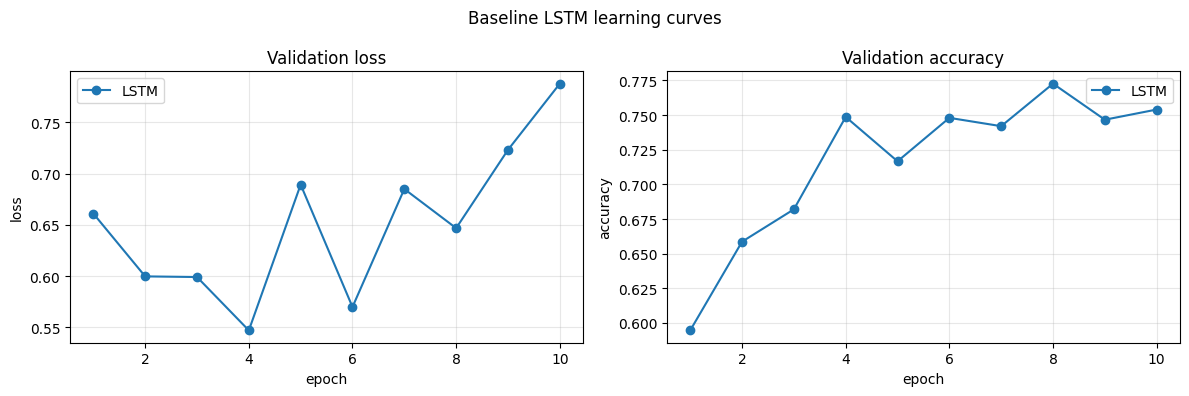

In [ ]:
def plot_curves(histories, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for name, h in histories.items():
        ep = range(1, len(h['train_loss']) + 1)
        ax[0].plot(ep, h['val_loss'], marker='o', label=name)
        ax[1].plot(ep, h['val_acc'],  marker='o', label=name)
    ax[0].set(title='Validation loss', xlabel='epoch', ylabel='loss')
    ax[1].set(title='Validation accuracy', xlabel='epoch', ylabel='accuracy')
    for a in ax: a.legend(); a.grid(alpha=0.3)
    plt.suptitle(title); plt.tight_layout(); plt.show()


plot_curves({'LSTM': hist_lstm}, 'Baseline LSTM learning curves')

In [ ]:
lstm.eval()
label_name = {0: 'NEG', 1: 'POS'}
with torch.no_grad():
    idxs = [0, 1, 2, 3, 4, 5]
    xb = X_test[idxs].to(device)
    probs = F.softmax(lstm(xb), dim=1).cpu()
    preds = probs.argmax(1)

for row, i in enumerate(idxs):
    txt = test_raw[i]['text'][:160].replace('\n', ' ')
    ok = 'True' if preds[row].item() == y_test[i].item() else 'False'
    print(f"{ok} pred {label_name[preds[row].item()]} "
          f"(p={probs[row, preds[row]].item():.2f}) | "
          f"true {label_name[y_test[i].item()]} | {txt}...")

False pred NEG (p=1.00) | true POS | This movie was awesome. It's a documentary about how surfing influenced skateboarding in the early days. It has interviews with skaters such as Tony Hawk(my ido...
True pred POS (p=0.60) | true POS | When the Italians and Miles O'keeffe work together nothing can go wrong! As ever, Miles is great as the almost as great Ator; the most lovable barbarian of all ...
True pred NEG (p=0.71) | true NEG | Forget what I said about Emeril. Rachael Ray is the most irritating personality on the Food Network AND all of television. If you've never seen 30 Minute Meals,...
True pred POS (p=0.62) | true POS | This is one of my 3 favorite movies. I've been out on the water since I was 13, so I got a lot of the humor as well as recognizing a lot of the near-land scener...
False pred POS (p=1.00) | true NEG | Oh boy ! It was just a dream ! What a great idea ! Mr Lynch is very lucky most people try to tell classical stories. This way he can play with his little planti..

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
lstm.eval()
all_pred, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_pred.append(lstm(xb.to(device)).argmax(1).cpu())
        all_true.append(yb)
cm = confusion_matrix(torch.cat(all_true), torch.cat(all_pred))

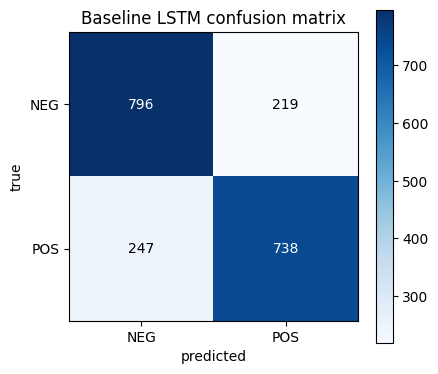

In [ ]:
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=['NEG', 'POS'],
       yticklabels=['NEG', 'POS'], xlabel='predicted', ylabel='true',
       title='Baseline LSTM confusion matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im); plt.tight_layout(); plt.show()


In [ ]:
models = {
    'RNN':  RecurrentClassifier(kind='rnn',  hidden_size=128),
    'LSTM': RecurrentClassifier(kind='lstm', hidden_size=128),
    'GRU':  RecurrentClassifier(kind='gru',  hidden_size=128),
    'CNN':  CNN1DClassifier(),
}
histories, test_scores = {}, {}
for name, m in models.items():
    set_seed(0)
    histories[name] = train_model(m, train_loader, val_loader, epochs=5,
                                  label=name, verbose=False)
    _, acc = evaluate(m, test_loader)
    test_scores[name] = acc
    print(f'{name:5s} | test acc {acc:.3f} | params {count_params(m):>9,} | '
          f'{histories[name]["time"]:.1f}s')

RNN   | test acc 0.646 | params 2,029,698 | 11.9s
LSTM  | test acc 0.761 | params 2,118,018 | 12.0s
GRU   | test acc 0.756 | params 2,088,578 | 11.9s
CNN   | test acc 0.813 | params 2,120,902 | 6.6s


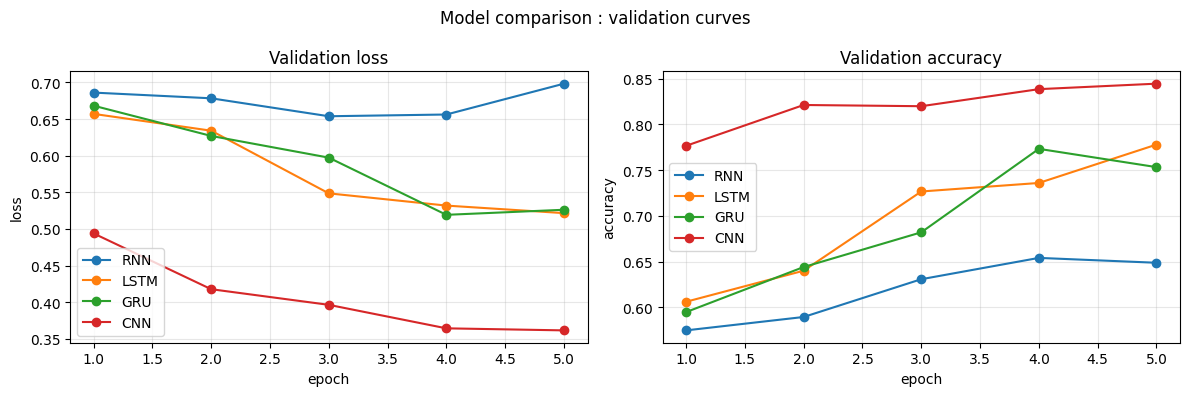

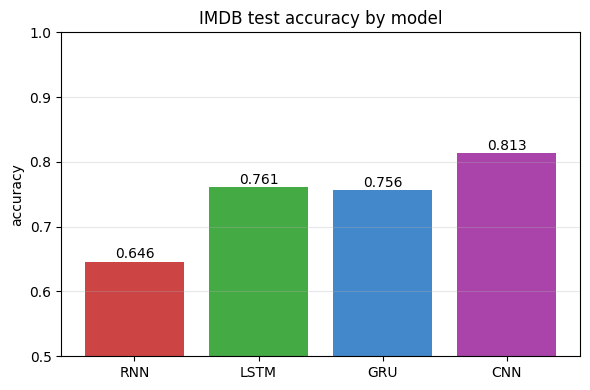

In [ ]:
plot_curves(histories, 'Model comparison : validation curves')

fig, ax = plt.subplots(figsize=(6, 4))
names = list(test_scores); accs = [test_scores[n] for n in names]
bars = ax.bar(names, accs, color=['#c44', '#4a4', '#48c', '#a4a'])
ax.set(title='IMDB test accuracy by model', ylabel='accuracy', ylim=(0.5, 1))
for b, a in zip(bars, accs):
    ax.text(b.get_x()+b.get_width()/2, a+0.005, f'{a:.3f}', ha='center')
ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
POS_WORDS = [w for w in ['brilliant', 'excellent', 'wonderful', 'superb', 'great'] if w in stoi]
NEG_WORDS = [w for w in ['terrible', 'awful', 'horrible', 'boring', 'worst'] if w in stoi]
FILLER    = [w for w in ['the', 'a', 'and', 'of', 'to', 'movie', 'film', 'it'] if w in stoi]
print('polar words available:', POS_WORDS, NEG_WORDS)

polar words available: ['brilliant', 'excellent', 'wonderful', 'superb', 'great'] ['terrible', 'awful', 'horrible', 'boring', 'worst']
